# Movilidad urbana y economía · 2024
**Mario Alberto Vivero · Proyecto académico de análisis de datos**

¿Cómo se relaciona el indicador de congestión `JamsDelay` con el PIB per cápita en las ciudades de la muestra?

Esta versión revisada parte del CSV consolidado del proyecto. La preparación histórica se documenta por separado. Las correlaciones y los gráficos de dispersión son ampliaciones de la revisión para contrastar la interpretación original; no demuestran causalidad.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'data').is_dir():
    ROOT = ROOT.parent
df = pd.read_csv(ROOT / 'data/ladb_mobility_economy_2024_clean.csv')
print(df.head().to_string(index=False))


          City country  Year   JamsDelay  TrafficIndexLive  JamsLengthInKms  JamsCount  MinsDelay  city_gdp_capita  unemployment_pct PM2.5 (μg/m³)  population
belo-horizonte     BRA  2024  263.047879         19.428946        44.038129  68.805422   0.487228          11124.0               9.5         16,80   6100000.0
        bogota     COL  2024 1141.552364         37.614273       140.893564 230.566550   1.699628          11442.0              10.0         17,60  11300000.0
      brasilia     BRA  2024  101.576326         11.258220        18.337133  27.280140   0.193442          16251.0               7.8         12,80   4800000.0
  buenos-aires     ARG  2024  571.089593         17.756012       100.287844 137.359860   0.416566          18117.0               7.2         14,50  15400000.0
      curitiba     BRA  2024  183.469274         14.954545        30.050044  46.898164   0.139965          12381.0               8.2         13,50   3700000.0


## Alcance y calidad del archivo
Se conserva el CSV aportado sin alteraciones. PM2.5 se convierte a número en memoria porque utiliza coma decimal. No se modifica el valor de PIB de Santiago (2277), que requiere cotejo con la fuente. La ausencia de nulos no garantiza la exactitud de los datos.


In [2]:
df['PM2.5 (μg/m³)'] = pd.to_numeric(
    df['PM2.5 (μg/m³)'].astype(str).str.replace(',', '.', regex=False), errors='raise'
)
print('Filas:', len(df))
print('Ciudades:', df['City'].nunique())
print('Países:', df['country'].nunique())
print('Años:', sorted(df['Year'].unique().tolist()))
print('Nulos:', int(df.isna().sum().sum()))
print('Claves ciudad-país-año duplicadas:', int(df.duplicated(['City','country','Year']).sum()))
print(df.loc[df['City'].eq('santiago'), ['City','city_gdp_capita']].to_string(index=False))


Filas: 15
Ciudades: 15
Países: 7
Años: [2024]
Nulos: 0
Claves ciudad-país-año duplicadas: 0
    City  city_gdp_capita
santiago           2277.0


## Distribución de congestión
`JamsDelay` se presenta con su nombre original. No se interpreta como minutos perdidos por persona o viaje: falta un diccionario de datos que confirme la unidad y el alcance del indicador. Los valores corresponden a promedios de las observaciones disponibles, no necesariamente a una cobertura completa del año.


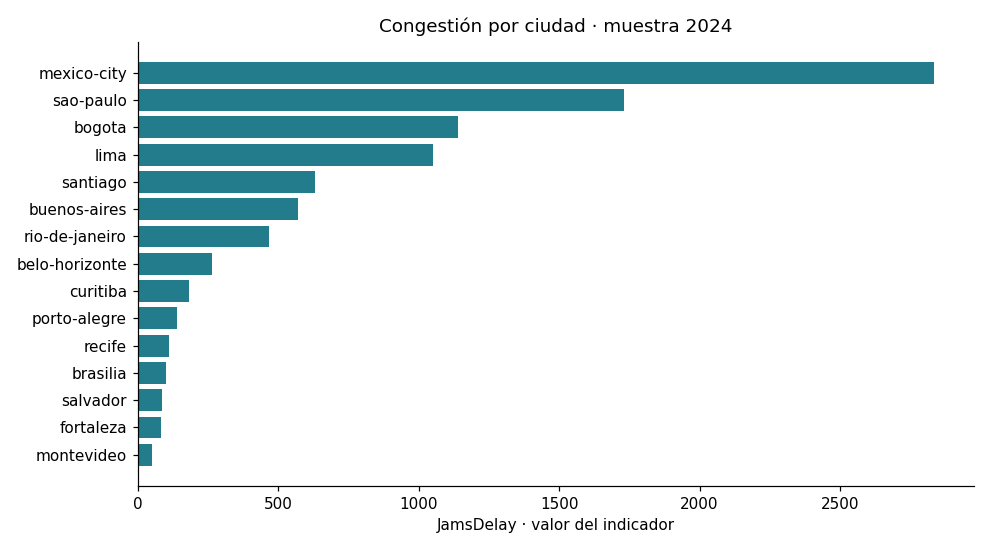

       City   JamsDelay
mexico-city 2833.057892
  sao-paulo 1729.189270
     bogota 1141.552364


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ranking = df.sort_values('JamsDelay')
ax.barh(ranking['City'], ranking['JamsDelay'], color='#237c8b')
ax.set(xlabel='JamsDelay · valor del indicador', title='Congestión por ciudad · muestra 2024')
ax.spines[['top','right']].set_visible(False)
fig.tight_layout()
(ROOT / 'images').mkdir(exist_ok=True)
fig.savefig(ROOT / 'images/congestion_por_ciudad.png', dpi=160)
plt.show()
print(df.nlargest(3, 'JamsDelay')[['City','JamsDelay']].to_string(index=False))


## Relación entre congestión y PIB per cápita
Un gráfico de dispersión permite comparar variables de distinta escala sin mezclarlas en un mismo eje de barras. La unidad monetaria y la comparabilidad del PIB deben confirmarse en la fuente.


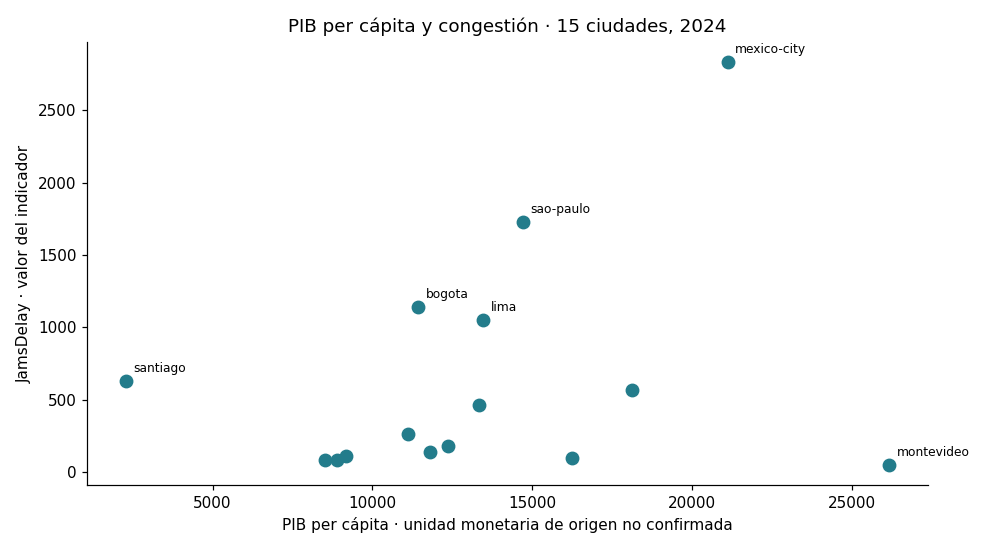

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['city_gdp_capita'], df['JamsDelay'], s=65, color='#237c8b')
for city in ['mexico-city','bogota','lima','montevideo','santiago','sao-paulo']:
    row = df.loc[df['City'].eq(city)].iloc[0]
    ax.annotate(city, (row['city_gdp_capita'], row['JamsDelay']),
                xytext=(5, 6), textcoords='offset points', fontsize=8)
ax.set(xlabel='PIB per cápita · unidad monetaria de origen no confirmada',
       ylabel='JamsDelay · valor del indicador',
       title='PIB per cápita y congestión · 15 ciudades, 2024')
ax.spines[['top','right']].set_visible(False)
fig.tight_layout()
fig.savefig(ROOT / 'images/pib_congestion.png', dpi=160)
plt.show()


## Correlaciones descriptivas y sensibilidad
Cada ciudad recibe el mismo peso. Se calcula Pearson para describir la asociación lineal y se repite el cálculo excluyendo una ciudad a la vez en dos escenarios. Estas exclusiones son pruebas de sensibilidad, no decisiones de limpieza. No se realizan pruebas de significancia ni inferencia poblacional.


In [5]:
r = df['city_gdp_capita'].corr(df['JamsDelay'])
r_pop = df['population'].corr(df['JamsDelay'])
print(f'Pearson PIB–JamsDelay: {r:.3f}')
print(f'Pearson población–JamsDelay: {r_pop:.3f}')
for city in ['mexico-city','santiago']:
    subset = df.loc[~df['City'].eq(city)]
    value = subset['city_gdp_capita'].corr(subset['JamsDelay'])
    print(f'PIB–JamsDelay sin {city}: {value:.3f} (n={len(subset)})')


Pearson PIB–JamsDelay: 0.283
Pearson población–JamsDelay: 0.879
PIB–JamsDelay sin mexico-city: -0.025 (n=14)
PIB–JamsDelay sin santiago: 0.335 (n=14)


## Hallazgos y decisión

- Ciudad de México presenta el mayor `JamsDelay` de la muestra (2833.06), seguida de São Paulo (1729.19) y Bogotá (1141.55).
- La correlación lineal PIB–congestión es débil (r = 0.283) y sensible a Ciudad de México: al excluirla pasa a −0.025. No hay base para una conclusión general de que mayor PIB implique mayor o menor congestión.
- Población y `JamsDelay` presentan una asociación positiva alta en esta muestra (r = 0.879). Es una razón para estudiar el tamaño urbano y la definición del indicador, no evidencia de causalidad.
- Bogotá y Lima pueden incluirse en un diagnóstico más detallado por sus indicadores de congestión, pero este análisis no permite ordenar inversiones ni demostrar un efecto sobre productividad.

**Siguientes pasos:** confirmar unidades y el valor de Santiago; evaluar cobertura temporal y geográfica; incorporar capacidad vial, transporte público y métricas por viaje o habitante adecuadamente definidas; comparar alternativas con costos y beneficios antes de recomendar inversión.

**Límites:** 15 ciudades de 7 países, un solo año y selección condicionada por la unión de los datasets. El PIB per cápita se usa como indicador económico, no como medición directa de productividad laboral. No se atribuyen resultados a una intervención.
